In [7]:
import cv2
import torch
import numpy as np
import torchvision.transforms.functional as F
from torchvision.models.optical_flow import raft_large
import matplotlib.pyplot as plt

In [8]:
def find_most_moved_part(video_path):
    # 1. 모델 및 비디오 초기화
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = raft_large(pretrained=True).to(device).eval()

    cap = cv2.VideoCapture(video_path)
    ret, prev_frame = cap.read()
    if not ret:
        print("비디오를 읽을 수 없습니다.")
        return

    # 움직임 누적을 위한 맵 초기화
    h, w, _ = prev_frame.shape
    total_magnitude_map = torch.zeros((h, w), device=device)
    
    # 첫 프레임 전처리
    prev_frame_tensor = F.to_tensor(prev_frame).to(device)
    
    frame_count = 0
    while cap.isOpened():
        ret, current_frame = cap.read()
        if not ret:
            break

        # 현재 프레임 전처리
        current_frame_tensor = F.to_tensor(current_frame).to(device)

        # RAFT 입력 형식에 맞게 배치 차원 추가 및 정규화
        # 모델은 [B, C, H, W] 형태, -1 ~ 1 범위의 값을 기대
        b_prev = prev_frame_tensor.unsqueeze(0) * 2.0 - 1.0
        b_curr = current_frame_tensor.unsqueeze(0) * 2.0 - 1.0

        # 2. Optical Flow 계산
        with torch.no_grad():
            list_of_flows = model(b_prev, b_curr)
            flow = list_of_flows[-1].squeeze(0)  # [2, H, W]

        # 3. Magnitude 계산 및 누적
        magnitude = torch.sqrt(flow[0]**2 + flow[1]**2)
        total_magnitude_map += magnitude
        
        # 다음 루프를 위해 현재 프레임을 이전 프레임으로 설정
        prev_frame = current_frame
        prev_frame_tensor = current_frame_tensor
        frame_count += 1
        print(f"{frame_count} 프레임 처리 완료...")

    cap.release()

    # 4. 결과 시각화
    # CPU로 데이터 이동 및 NumPy 배열로 변환
    total_magnitude_map_np = total_magnitude_map.cpu().numpy()

    # 히트맵 생성
    # 0~255 범위로 정규화
    heatmap_normalized = cv2.normalize(total_magnitude_map_np, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    heatmap_color = cv2.applyColorMap(heatmap_normalized, cv2.COLORMAP_JET)

    # 비디오의 마지막 프레임 위에 히트맵 오버레이
    last_frame_bgr = cv2.cvtColor(prev_frame, cv2.COLOR_RGB2BGR) # Matplotlib은 RGB, OpenCV는 BGR
    overlayed_image = cv2.addWeighted(last_frame_bgr, 0.6, heatmap_color, 0.4, 0)

    # 결과 표시
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(last_frame_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Original Last Frame")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlayed_image, cv2.COLOR_BGR2RGB))
    plt.title("Motion Heatmap Overlayed")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

1 프레임 처리 완료...
2 프레임 처리 완료...
3 프레임 처리 완료...
4 프레임 처리 완료...
5 프레임 처리 완료...
6 프레임 처리 완료...
7 프레임 처리 완료...
8 프레임 처리 완료...
9 프레임 처리 완료...
10 프레임 처리 완료...
11 프레임 처리 완료...
12 프레임 처리 완료...
13 프레임 처리 완료...
14 프레임 처리 완료...
15 프레임 처리 완료...
16 프레임 처리 완료...
17 프레임 처리 완료...
18 프레임 처리 완료...
19 프레임 처리 완료...


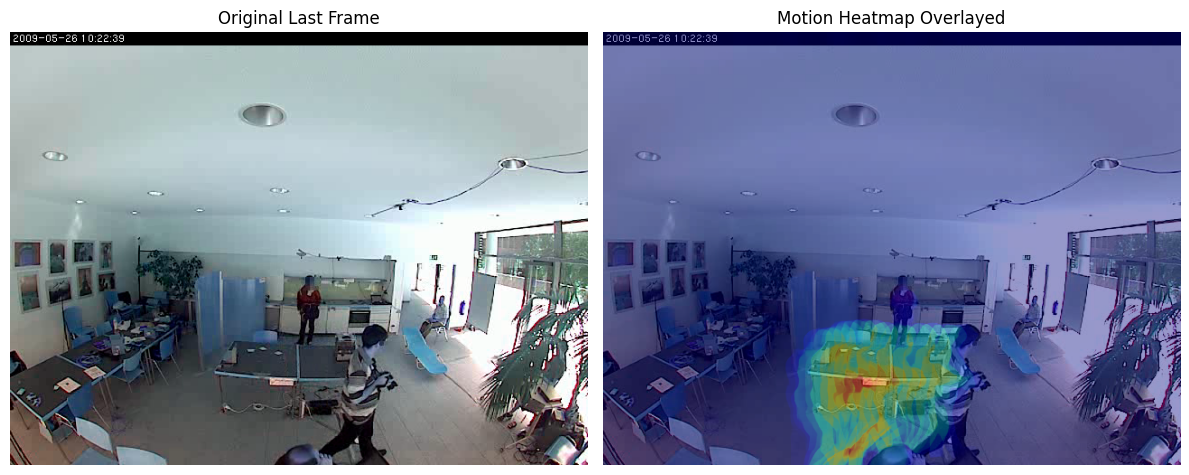

In [9]:
# 사용 예시 (실제 비디오 파일 경로를 입력하세요)
find_most_moved_part("/mnt/hdd4tb/junho/Opportunity++/data_processed_2s_window/trim_2s_video/S2-ADL1/S2-ADL1_001041000_001043000.mp4")